In [7]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib
import matplotlib as mpl
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
%matplotlib inline
import seaborn as sns
import os
import pyreadr
from scipy.stats import mannwhitneyu

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [9]:
path0="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v1.min40_split"
dftis = pd.read_csv(f'{path0}/../tissue40.list', sep='\t')
tislist = list(dftis['Tissue'])
tisorder = pd.read_csv("/storage/public/home/2020060185/jupyter/sheepGTEx/00.metadata/tissue.order",sep="\t")
palette = tisorder.set_index('Tissue (QTL)')['Color'].to_dict()

In [3]:
# results referred to: https://stephenslab.github.io/mashr/articles/intro_mash.html#step-4-extract-posterior-summaries
path="/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v6.tissue_sharing"
lfsr = dict()
lfsr_all = dict()
pm = dict()
pm_all = dict()
lfsr_logi = dict()
lfsr_logi_gene = dict()
lfsr_logi_gene_count = dict()

for i, rank in enumerate(['lead', 'rank1', 'rank2', 'rank3', 'rank4', 'lead_downsample100']):
    print(rank)
    # input data
    lfsr[rank] = pyreadr.read_r(f"{path}/0{i}.{rank}/output/top_pairs/lfsr_m.s.RDS")[None]
    lfsr_all[rank] = pyreadr.read_r(f"{path}/0{i}.{rank}/output/top_pairs_across_all/lfsr_m.s.RDS")[None]
    pm[rank] = pyreadr.read_r(f"{path}/0{i}.{rank}/output/top_pairs/pm_m.s.RDS")[None]
    pm_all[rank] = pyreadr.read_r(f"{path}/0{i}.{rank}/output/top_pairs_across_all/pm_m.s.RDS")[None]
    # get significant shared eQTL
    lfsr_logi[rank] = (lfsr[rank]<0.05).reset_index().rename(columns={'index': 'pairs'})
    lfsr_logi[rank]['variant_id'] = lfsr_logi[rank]['pairs'].str.split(',', expand=True)[0]
    lfsr_logi[rank]['phenotype_id'] = lfsr_logi[rank]['pairs'].str.split(',', expand=True)[1]
    # get significant shared tissues per eGene
    lfsr_logi_gene[rank] = lfsr_logi[rank].groupby('phenotype_id').sum().iloc[:,1:-1]>0
    # count shared tissues per eGene
    lfsr_logi_gene_count[rank] = lfsr_logi_gene[rank].sum(axis=1).reset_index(name='Tissues with LFSR < 0.05')

lead
rank1
rank2
rank3
rank4
lead_downsample100


In [4]:
for i, rank in enumerate(['lead', 'rank1', 'rank2', 'rank3', 'rank4']):
    print(rank)
    df_lfsr_gene_merged = pd.merge(lfsr_logi_gene_count[rank], lfsr_logi_gene[rank], on='phenotype_id')
#    df_lfsr_gene_merged.to_csv(f'{path}/0{i}.{rank}/lfsr_sig_gene.count.txt', sep="\t",index=False)

lead
rank1
rank2
rank3
rank4


In [5]:
df_lead = pd.DataFrame()
rank = 'lead'
df_lfsr = (lfsr[rank]<0.05).sum(axis=1).reset_index().rename(columns={'index': 'pairs', 0: 'Tissues with LFSR < 0.05'})
df_lfsr['variant_id'] = df_lfsr['pairs'].str.split(',', expand=True)[0]
df_lfsr['phenotype_id'] = df_lfsr['pairs'].str.split(',', expand=True)[1]
df_lfsr['Type'] = 'eQTL'
df_lfsr_all = (lfsr_all[rank]<0.05).sum(axis=1).reset_index().rename(columns={'index': 'pairs', 0: 'Tissues with LFSR < 0.05'})
df_lfsr_all['variant_id'] = df_lfsr_all['pairs'].str.split(',', expand=True)[0]
df_lfsr_all['phenotype_id'] = df_lfsr_all['pairs'].str.split(',', expand=True)[1]
df_lfsr_all['Type'] = 'eQTL tested in all tissues'
df_lead = pd.concat([df_lfsr, df_lfsr_all])
df_lead = df_lead[df_lead['Tissues with LFSR < 0.05']>0]

# Fig. 5d

In [39]:
# get significant shared genes per tissue
kme = pd.DataFrame()
for tis in tislist:
    kme_path = f"/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/01.MP1/02.stat/04.MP1/gene/featureCount/WGCNA/WGCNA_new/WGCNA/{tis}/02.gene_kME_{tis}.csv"
    kme_ = pd.read_csv(kme_path)
    kme_['|kME|'] = kme_['kME_value'].abs()
    kme_['Tissue'] = tis
    lfsr_geneset = set(lfsr_logi['lead'].loc[lfsr_logi['lead'][tis], 'phenotype_id'])
    kme = pd.concat([kme, kme_[kme_['GeneID'].isin(lfsr_geneset)]])
kme

,GeneID,module,kME_value,|kME|,Tissue
0,A1BG,kME_ME0,0.179256,0.179256,Muscle
1,A4GALT,kME_ME0,0.101641,0.101641,Muscle
3,AACS,kME_ME0,0.039329,0.039329,Muscle
4,AADACL3,kME_ME0,0.028560,0.028560,Muscle
5,AAGAB,kME_ME0,-0.162971,0.162971,Muscle
...,...,...,...,...,...
19623,ZYG11A,kME_ME0,-0.008649,0.008649,Oviduct
19624,ZYG11B,kME_ME1,0.431743,0.431743,Oviduct
19625,ZYX,kME_ME9,0.820933,0.820933,Oviduct
19626,ZZEF1,kME_ME12,0.417622,0.417622,Oviduct


In [40]:
# count shared tissues per eGene
kme_count = kme.groupby('GeneID').size().reset_index(name='Tissues with LFSR < 0.05')
kme_lfsr = pd.merge(kme, kme_count, on="GeneID")
kme_lfsr

,GeneID,module,kME_value,|kME|,Tissue,Tissues with LFSR < 0.05
0,A1BG,kME_ME0,0.179256,0.179256,Muscle,51
1,A4GALT,kME_ME0,0.101641,0.101641,Muscle,18
2,AACS,kME_ME0,0.039329,0.039329,Muscle,51
3,AADACL3,kME_ME0,0.028560,0.028560,Muscle,51
4,AAGAB,kME_ME0,-0.162971,0.162971,Muscle,51
...,...,...,...,...,...,...
620420,ZYG11A,kME_ME0,-0.008649,0.008649,Oviduct,49
620421,ZYG11B,kME_ME1,0.431743,0.431743,Oviduct,41
620422,ZYX,kME_ME9,0.820933,0.820933,Oviduct,43
620423,ZZEF1,kME_ME12,0.417622,0.417622,Oviduct,51


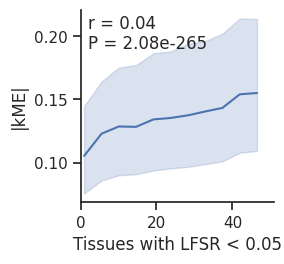

In [41]:
# egenes
sns.set_theme(style="ticks")
plt.figure(figsize=(2.5, 2.5))

kme_lfsr['bins'] = pd.cut(kme_lfsr['Tissues with LFSR < 0.05'], bins=11)
kme_lfsr['bin_min'] = kme_lfsr['bins'].apply(lambda x: x.left)
r, P = stats.pearsonr(kme_lfsr['Tissues with LFSR < 0.05'], kme_lfsr['|kME|'])
ax = sns.lineplot(data=kme_lfsr, x="bin_min", y='|kME|', estimator="median", errorbar=("pi", 25))
if P:
    ax.text(2, 0.19, f'r = {r:.2f}\nP = {P:.2e}')
else:
    ax.text(2, 0.19, f'r = {r:.2f}\nP < 2.225e-308')
plt.xlabel('Tissues with LFSR < 0.05')
plt.xlim(0, 51)

sns.despine()
plt.savefig('pdf/eqtl_KME.pdf', bbox_inches='tight')

# Fig. 5e

In [9]:
from scipy.stats import fisher_exact

# 定义计算fold enrichment值和95%置信区间的函数
def calculate_fold_enrichment(target_count, target_total, background_count, background_total):
    # 检查零值
    if target_count == 0 or target_total == 0 or background_count == 0 or background_total == 0:
        fe_value = float('inf') if (target_count * background_total > background_count * target_total) else 0
        ci_low, ci_high = (0, float('inf'))
        p_value = 1.0  # 如果不能计算，则P值设为1
        return fe_value, ci_low, ci_high, p_value

    # 计算目标组中某一项的比例
    target_ratio = target_count / target_total
    # 计算背景组中相同项的比例
    background_ratio = background_count / background_total
    # 计算 Fold Enrichment
    fe_value = target_ratio / background_ratio

    # 使用scipy计算P值和置信区间 (公式)
    table = [[target_count, target_total - target_count],
             [background_count, background_total - background_count]]
    _, p_value = fisher_exact(table, alternative='two-sided')
    
    # 计算标准误差和置信区间
    se = np.sqrt(1/target_count + 1/(target_total - target_count) + 1/background_count + 1/(background_total - background_count))
    ci_low = np.exp(np.log(fe_value) - 1.96 * se)
    ci_high = np.exp(np.log(fe_value) + 1.96 * se)

    return fe_value, ci_low, ci_high, p_value

def get_control_snps(maf_ld_data, ld_sd, qtl_snps_set, maf_match, ld_match, permutations):
    qtl_snps_set_control = set()
    for snp in list(qtl_snps_set):
        # 找到该 SNP 的信息
        if snp not in maf_ld_data.index:
            continue
        focal_maf = maf_ld_data.at[snp, "MAF"]
        focal_ld = maf_ld_data.at[snp, "ldscore"]
        maf_low = focal_maf - maf_match
        maf_high = focal_maf + maf_match
        ld_low = focal_ld - ld_match * ld_sd
        ld_high = focal_ld + ld_match * ld_sd
        
        # 筛选符合条件的 SNP
        candidates = maf_ld_data[
            (maf_ld_data["MAF"].between(maf_low, maf_high)) &
            (maf_ld_data["ldscore"].between(ld_low, ld_high))
        ]
        candidates = candidates.drop(index=snp, errors="ignore")
        candidates = candidates[~candidates.index.isin(qtl_snps_set)]

        # 随机选择n个
        if len(candidates) >= permutations:
            matched = np.random.choice(candidates.index, permutations, replace=False)
        else:
            matched = candidates.index.values
        
        qtl_snps_set_control.update(matched)
    return qtl_snps_set_control

# promoter & enhancer集合
annotation_files = ['/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/functional_enrichment/promoter.txt',
                    '/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/functional_enrichment/enhancer.txt']
annotation_data = {os.path.basename(file): pd.read_csv(file, header=None, names=['SNP']).squeeze("columns") for file in annotation_files}

# control SNPs
maf_ld_file = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/admixture/chrAuto.filtered.keep.score.ld"
maf_ld_data = pd.read_csv(maf_ld_file, sep=' ').dropna().set_index("SNP")
ld_sd = maf_ld_data['ldscore'].std()

# 总SNP集合
site_file = '/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/functional_enrichment/allsnp.txt'
all_snps = set(pd.read_csv(site_file, header=None).squeeze("columns"))

In [ ]:
# 结果存储列表
results = []
results_control = []
qtl_snps_set_control = set()

# 逐一计算每种类型QTL和功能注释的OR值及95%置信区间
for i in range(1, 52):
    qtl_snps_set = set(df_lfsr[df_lfsr['Tissues with LFSR < 0.05']==i]['variant_id'])

    # 提取MAF-matched和LD-matched control SNPs，保证至少10个重复，且大于1000个位点
    num_var = len(qtl_snps_set)
    if num_var > 1000:
        qtl_snps_set_control = get_control_snps(maf_ld_data, ld_sd, qtl_snps_set, 0.02, 0.1, 10)
    elif num_var > 10:
        qtl_snps_set_control = get_control_snps(maf_ld_data, ld_sd, qtl_snps_set, 0.02, 0.1, 100)
    else:
        qtl_snps_set_control = get_control_snps(maf_ld_data, ld_sd, qtl_snps_set, 0.02, 0.1, 1000)
    #print(i, num_var, len(qtl_snps_set_control))

    for annotation_name, annotation_snps in annotation_data.items():
        annotation_snps_set = set(annotation_snps)
        num_var = len(qtl_snps_set)
        
        # focal SNPs
        ## 构建2x2列联表
        target_count = len(qtl_snps_set & annotation_snps_set)
        target_total = len(qtl_snps_set)
        background_count = len(annotation_snps_set)
        background_total = len(all_snps)
        ## 计算FE值和置信区间
        fe_value, ci_low, ci_high, p_value = calculate_fold_enrichment(target_count, target_total, background_count, background_total)
        ## 存储结果
        results.append([i, annotation_name, fe_value, ci_low, ci_high, p_value])
        
        # control SNPs
        num_var = len(qtl_snps_set_control)
        ## 构建2x2列联表
        target_count = len(qtl_snps_set_control & annotation_snps_set)
        target_total = len(qtl_snps_set_control)
        background_count = len(annotation_snps_set)
        background_total = len(all_snps)
        ## 计算FE值和置信区间
        fe_value, ci_low, ci_high, p_value = calculate_fold_enrichment(target_count, target_total, background_count, background_total)
        ## 存储结果
        results_control.append([i, annotation_name, fe_value, ci_low, ci_high, p_value])
        
# 将结果转换为DataFrame并保存
results_df = pd.DataFrame(results, columns=['Tissues with LFSR < 0.05', 'Annotation', 'Fold enrichment', '95% CI Low', '95% CI High', 'P-value'])
results_df['Annotation'] = results_df['Annotation'].str.replace('.txt', '', regex=False)
results_control_df = pd.DataFrame(results_control, columns=['Tissues with LFSR < 0.05', 'Annotation', 'Fold enrichment', '95% CI Low', '95% CI High', 'P-value'])
results_control_df['Annotation'] = results_control_df['Annotation'].str.replace('.txt', '', regex=False)
#results_df.to_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v6.tissue_sharing/00.lead/FE_results.csv', index=False)
#results_control_df.to_csv('/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v6.tissue_sharing/00.lead/FE_control_results.csv', index=False)

In [12]:
#results_df = pd.read_csv(f'/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v6.tissue_sharing/00.lead/FE_results.csv')
promoter_df = results_df[results_df['Annotation']=="promoter"]
enhancer_df = results_df[results_df['Annotation']=="enhancer"]

#results_control_df = pd.read_csv(f'/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v6.tissue_sharing/00.lead/FE_results.csv')
promoter_control_df = results_control_df[results_control_df['Annotation']=="promoter"]
enhancer_control_df = results_control_df[results_control_df['Annotation']=="enhancer"]

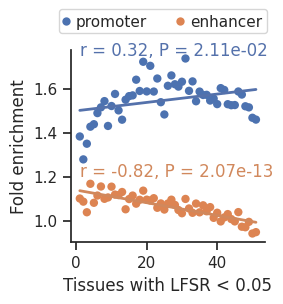

In [43]:
from sklearn.linear_model import LinearRegression

sns.set_theme(style="ticks")
fig = plt.figure(figsize=(2.5, 2.5))

ax = sns.scatterplot(data=results_df, x="Tissues with LFSR < 0.05", y="Fold enrichment", hue="Annotation", linewidth=0)
sns.move_legend(ax, "upper left", title=None, ncols=2, bbox_to_anchor=(-0.1, 1.25),
                borderpad=0.3, handlelength=0.3, handletextpad=0.5)

# lm plot (promoter)
model = LinearRegression()
model.fit(promoter_df[["Tissues with LFSR < 0.05"]], promoter_df['Fold enrichment'])
y_pred1 = model.predict(promoter_df[["Tissues with LFSR < 0.05"]])
plt.plot(promoter_df["Tissues with LFSR < 0.05"], y_pred1, color='#5471ab', linewidth=2, label='Promoter')

r1, P1 = stats.pearsonr(promoter_df["Tissues with LFSR < 0.05"],promoter_df['Fold enrichment'])
plt.text(1, 1.75, f'r = {r1:.2f}, P = {P1:.2e}', color='#5471ab')

# lm plot (enhancer)
model = LinearRegression()
model.fit(enhancer_df[["Tissues with LFSR < 0.05"]], enhancer_df['Fold enrichment'])
y_pred2 = model.predict(enhancer_df[["Tissues with LFSR < 0.05"]])
plt.plot(enhancer_df["Tissues with LFSR < 0.05"], y_pred2, color='#d1885c', linewidth=2, label='Enhancer')

r2, P2 = stats.pearsonr(enhancer_df["Tissues with LFSR < 0.05"],enhancer_df['Fold enrichment'])
plt.text(1, 1.2, f'r = {r2:.2f}, P = {P2:.2e}', color='#d1885c')

sns.despine()
plt.savefig('pdf/lfsr_enrichment.pdf', dpi='figure', format='pdf', bbox_inches='tight')

ymin, ymax = ax.get_ylim()

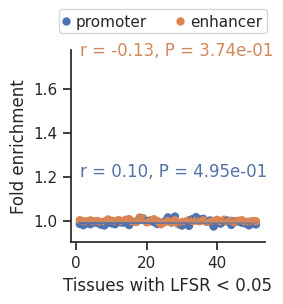

In [47]:
from sklearn.linear_model import LinearRegression

sns.set_theme(style="ticks")
fig = plt.figure(figsize=(2.5, 2.5))

ax = sns.scatterplot(data=results_control_df, x="Tissues with LFSR < 0.05", y="Fold enrichment", hue="Annotation", linewidth=0)
ax.set_ylim(ymin, ymax)
sns.move_legend(ax, "upper left", title=None, ncols=2, bbox_to_anchor=(-0.1, 1.25),
                borderpad=0.3, handlelength=0.3, handletextpad=0.5)


# lm plot (promoter)
model = LinearRegression()
model.fit(promoter_control_df[["Tissues with LFSR < 0.05"]], promoter_control_df['Fold enrichment'])
y_pred1 = model.predict(promoter_control_df[["Tissues with LFSR < 0.05"]])
plt.plot(promoter_control_df["Tissues with LFSR < 0.05"], y_pred1, color='#5471ab', linewidth=2, label='Promoter')

r1, P1 = stats.pearsonr(promoter_control_df["Tissues with LFSR < 0.05"],promoter_control_df['Fold enrichment'])
plt.text(1, 1.2, f'r = {r1:.2f}, P = {P1:.2e}', color='#5471ab')

# lm plot (enhancer)
model = LinearRegression()
model.fit(enhancer_control_df[["Tissues with LFSR < 0.05"]], enhancer_control_df['Fold enrichment'])
y_pred2 = model.predict(enhancer_df[["Tissues with LFSR < 0.05"]])
plt.plot(enhancer_control_df["Tissues with LFSR < 0.05"], y_pred2, color='#d1885c', linewidth=2, label='Enhancer')

r2, P2 = stats.pearsonr(enhancer_control_df["Tissues with LFSR < 0.05"],enhancer_control_df['Fold enrichment'])
plt.text(1, 1.75, f'r = {r2:.2f}, P = {P2:.2e}', color='#d1885c')

sns.despine()
plt.savefig('pdf/lfsr_enrichment_control.pdf', dpi='figure', format='pdf', bbox_inches='tight')

# Fig. 5f

In [4]:
path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v6.tissue_sharing/oppo_effect"
df = pd.read_csv(f"{path}/oppo_effect_eqtl.txt", sep="\t",
                  usecols=['tissue1', 'tissue2', 'phenotype_id', 'chrom', 'variant_id1', 'pval_nominal1', 'slope1', 'slope_se1', 'shared1',
                           'variant_id2', 'pval_nominal2', 'slope2', 'slope_se2', 'shared2', 'PP.H4.abf', 'r2_min', 'type'])
df['chrom'] = 'chr' + df['variant_id1'].str.split('_', expand=True)[0]
#df['sorted_pair'] = df.apply(lambda row: tuple(sorted([row['tissue1'], row['tissue2']])), axis=1)

In [5]:
df_filter = df[(df['r2_min']>=0.8)&(df['shared1']==True)&(df['shared2']==True)]
#df_filter.to_csv(f"{path}/oppo_effect_eqtl.filtered.txt", index=None, sep="\t")
#df_filter = pd.read_csv(f"{path}/oppo_effect_eqtl.filtered.txt", sep="\t")

In [10]:
df_summary = pd.DataFrame()
for tis in tislist:
    df_ = df_filter[(df_filter['tissue1']==tis)|(df_filter['tissue2']==tis)]
    df_count_ = df_['type'].value_counts().to_frame().T.reset_index().rename(columns={'index':'tissue'}).replace('count', tis)
    df_summary = pd.concat([df_summary, df_count_])
df_summary = df_summary.fillna(0)
df_summary = df_summary.merge(tisorder[['System', 'Tissue (QTL)', 'Color']].rename(columns={'Tissue (QTL)':'tissue'}), on='tissue')
df_summary['sum'] = df_summary[['Homogeneous','Heterogeneous','Opposite']].sum(axis=1)
df_summary = df_summary.replace('_', ' ', regex=True)

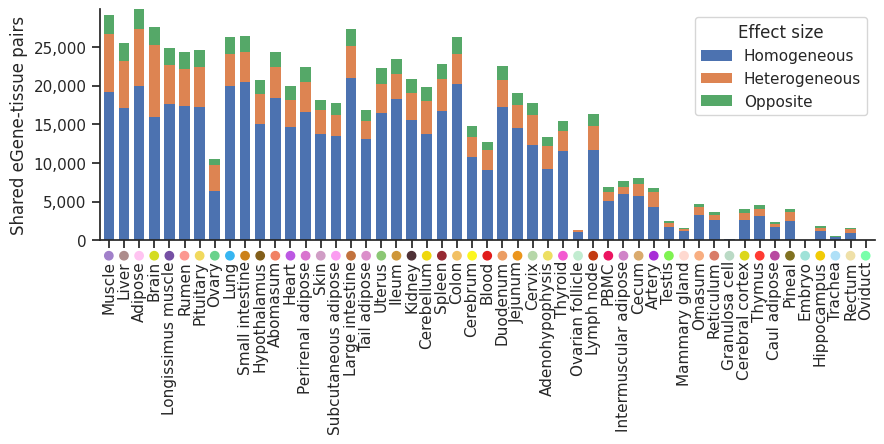

In [73]:
sns.set_theme(style="ticks")
fig=plt.figure(figsize=(10, 3))
ax = fig.add_subplot()

df_summary[['Homogeneous','Heterogeneous','Opposite']].plot(kind='bar', stacked=True, ax=ax, linewidth=0, width=0.7)
ax.set_ylabel('Shared eGene-tissue pairs')
#ax.set_xlabel('')
x = np.arange(df_summary.shape[0])
ax.set_ylim([0, df_summary['sum'].max()])
ax.tick_params(axis='x', which='major')
ax.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

ax.scatter(x, -2000*np.ones(df_summary.shape[0]), c=df_summary['Color'], clip_on=False)
ax.set_xticklabels(df_summary['tissue'], rotation=90, ha='center', y=-0.03)
sns.move_legend(ax, "upper right", title='Effect size', bbox_to_anchor=(1, 1))
sns.despine()
#plt.savefig('pdf/shared_egene_tissue_pairs.pdf', bbox_inches='tight')

In [74]:
cols = ['Homogeneous', 'Heterogeneous', 'Opposite']
df_ratio = df_summary[['tissue', 'Homogeneous', 'Heterogeneous', 'Opposite', 'sum']]
for col in cols:
    df_ratio[col + '_ratio'] = df_ratio[col] / df_ratio['sum']
df_ratio[['Homogeneous_ratio', 'Heterogeneous_ratio', 'Opposite_ratio']].mean()

/tmp/ipykernel_672925/108313050.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ratio[col + '_ratio'] = df_ratio[col] / df_ratio['sum']


Homogeneous_ratio      0.717803
Heterogeneous_ratio    0.194253
Opposite_ratio         0.087944
dtype: float64

# Fig. 5g

In [309]:
label_mapping = {'intergenic_region':'intergenic','upstream_gene':'upstream','downstream_gene':'downstream','5_prime_UTR':"5' UTR",'3_prime_UTR':"3' UTR",
                 '5_prime_UTR_premature_start_codon_gain':"5' UTR premature\nstart codon gain",'non_coding_transcript_exon':'non-coding\ntranscript exon',
                 'splice_region':'splice region','splice_acceptor':'splice acceptor','splice_donor':'splice donor','start_lost':'start lost','stop_lost':'stop lost',
                 'stop_gained':'stop gained','stop_retained':'stop retained','initiator_codon':'initiator codon',
                 "E1":"TssA", "E2":"TssAHet", "E3":"TxFlnk", "E4":"TxFlnkWk", "E5":"TxFlnkHet", "E6":"EnhA", "E7":"EnhAMe", "E8":"EnhAWk",
                 "E9":"EnhAHet", "E10":"EnhPois", "E11":"ATAC_Is", "E12":"TssBiv", "E13":"Repr", "E14":"ReprWk", "E15":"Qui"}

path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v6.tissue_sharing/oppo_effect/enrichment"

# focal SNPs
df1 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/lead/OR_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/lead/OR_results.csv')
        df_['Tissue'] = tis
        df_['Type'] = 'QTL'
        df1 = pd.concat([df1, df_])
df1['QTL'] = df1['QTL'].str.replace('.txt', '', regex=False)
df1['Annotation'] = df1['Annotation'].str.replace('.txt', '', regex=False)
df1['Annotation'] = df1['Annotation'].str.replace('_variant', '', regex=False)
df1['log2(odds ratio)'] = np.log2(df1['Odds ratio'])
df1 = df1.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df1['Source'] = 'molQTL'

# control SNPs
df2 = pd.DataFrame()
for tis in tislist:
    if os.path.isfile(f'{path}/{tis}/lead/OR_control_results.csv'):
        df_ = pd.read_csv(f'{path}/{tis}/lead/OR_control_results.csv')
        df_['Tissue'] = tis
        df_['Type'] = 'QTL'
        df2 = pd.concat([df2, df_])
df2['QTL'] = df2['QTL'].str.replace('.txt', '', regex=False)
df2['Annotation'] = df2['Annotation'].str.replace('.txt', '', regex=False)
df2['Annotation'] = df2['Annotation'].str.replace('_variant', '', regex=False)
df2['log2(odds ratio)'] = np.log2(df2['Odds ratio'])
df2 = df2.replace([np.inf, -np.inf], np.nan).reset_index(drop=True).dropna()
df2['Source'] = 'Control'

# merge
df = pd.concat([df1, df2], ignore_index=True)
df_ontology = df[~df['Annotation'].str.startswith('E')].reset_index(drop=True)
df_state = df[df['Annotation'].str.startswith('E')].reset_index(drop=True)
df['Annotation'] = df['Annotation'].replace(label_mapping)
df_ontology['Annotation'] = df_ontology['Annotation'].replace(label_mapping)
df_state['Annotation'] = df_state['Annotation'].replace(label_mapping)
df

/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/storage/public/home/2020060185/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,QTL,Annotation,Odds ratio,95% CI Low,95% CI High,P-value,num_var,Tissue,Type,log2(odds ratio),Source
0,Heterogeneous,intergenic,0.805841,0.728052,0.891942,2.307257e-05,2212,Muscle,QTL,-0.311433,molQTL
1,Heterogeneous,downstream,2.279673,2.075701,2.503689,4.315762e-58,2212,Muscle,QTL,1.188827,molQTL
2,Heterogeneous,start lost,31.629892,7.794993,128.345224,1.975924e-03,2212,Muscle,QTL,4.983217,molQTL
3,Heterogeneous,5' UTR premature\nstart codon gain,4.070434,2.558139,6.476751,1.081413e-06,2212,Muscle,QTL,2.025183,molQTL
4,Heterogeneous,EnhAHet,0.800605,0.725359,0.883657,7.320453e-06,2212,Muscle,QTL,-0.320838,molQTL
...,...,...,...,...,...,...,...,...,...,...,...
8653,Heterogeneous,3' UTR,1.102672,0.897839,1.354236,3.504000e-01,3000,Oviduct,QTL,0.141004,Control
8654,Heterogeneous,intragenic,0.818617,0.439902,1.523372,6.656239e-01,3000,Oviduct,QTL,-0.288739,Control
8655,Heterogeneous,TxFlnkWk,0.904103,0.813913,1.004287,6.260573e-02,3000,Oviduct,QTL,-0.145442,Control
8656,Heterogeneous,TxFlnk,0.794314,0.713175,0.884684,1.872206e-05,3000,Oviduct,QTL,-0.332218,Control


/tmp/ipykernel_2030408/1075923606.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
/tmp/ipykernel_2030408/1075923606.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


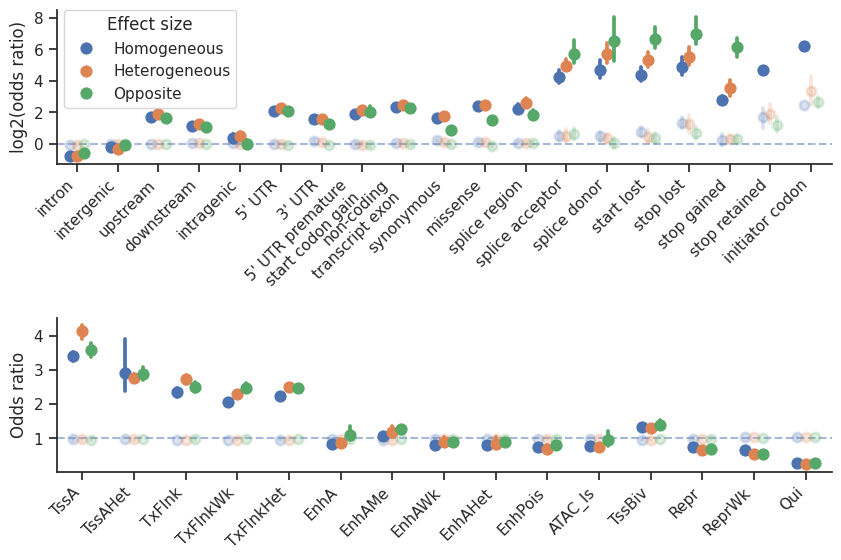

In [321]:
x_order1=['intron', 'intergenic', 'upstream', 'downstream', 'intragenic', "5' UTR","3' UTR", "5' UTR premature\nstart codon gain", 'non-coding\ntranscript exon',
          'synonymous', 'missense', 'splice region', 'splice acceptor', 'splice donor', 'start lost', 'stop lost', 'stop gained', 'stop retained', 'initiator codon']
x_order2=["TssA", "TssAHet", "TxFlnk", "TxFlnkWk", "TxFlnkHet", "EnhA", "EnhAMe", "EnhAWk", "EnhAHet", "EnhPois", "ATAC_Is", "TssBiv", "Repr", "ReprWk", "Qui"]

def plot_enrichment(ax, df, x_order, y_col, baseline, title=None, legend=True):
    ax.axhline(baseline, color="b", linestyle="--", alpha=0.5)

    # control (lead molQTL)
    sns.pointplot(data=df[df['Source']=="Control"], x="Annotation", y=y_col, hue="QTL", 
                  hue_order=['Homogeneous', 'Heterogeneous', 'Opposite'], legend=False,
                  order=x_order, markers="o", dodge=.35, alpha=.2, linestyles="none", ax=ax)
    
    # lead molQTL
    sns.pointplot(data=df[df['Source']=="molQTL"], x="Annotation", y=y_col, hue="QTL", 
                  hue_order=['Homogeneous', 'Heterogeneous', 'Opposite'], legend=legend,
                  order=x_order, markers="o", dodge=.35, linestyles="none", ax=ax)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_xlabel("")
    ax.set_title(title)

    return ax


sns.set_theme(style="ticks")
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
# ontology
plot_enrichment(ax=axes[0], df=df_ontology, x_order=x_order1, y_col="log2(odds ratio)", baseline=0, title="")
# chromatin state
plot_enrichment(ax=axes[1], df=df_state, x_order=x_order2, y_col="Odds ratio", baseline=1, title="", legend=False)
sns.move_legend(axes[0], "upper left", title='Effect size', bbox_to_anchor=(0,1.05))
sns.despine()
fig.subplots_adjust(hspace=1)
plt.savefig("pdf/tissue_shared_enrichment.pdf", dpi='figure', format='pdf', bbox_inches='tight')

# Fig. 5h

In [86]:
# load crhomatin states
import pyranges as pr
import os

df_ = pd.read_csv(f"{path}/tissue_GTEx2chromHMM.list", sep='\t')
mapping = (df_.groupby("GTEx")["HMM"].apply(list).to_dict())

bed_dict = {}
for fname in os.listdir(f'{path}/chromHMM_dense'):
    if fname.endswith("_18_dense.bed"):
        tissue = fname.replace("_18_dense.bed", "")
        bed_dict[tissue] = pr.read_bed(os.path.join(f'{path}/chromHMM_dense', fname))

#label_mapping = {1:"TssA", 2:"TssAHet", 3:"TxFlnk", 4:"TxFlnkWk", 5:"TxFlnkHet", 6:"EnhA", 7:"EnhAMe", 8:"EnhAWk",
#                     9:"EnhAHet", 10:"EnhPois", 11:"ATAC_Is", 12:"TssBiv", 13:"Repr", 14:"ReprWk", 15:"Qui"}
label_mapping = {1:"Tss", 2:"Tss", 3:"TxFlnk", 4:"TxFlnk", 5:"TxFlnk", 6:"Enh", 7:"Enh", 8:"Enh",
                     9:"Enh", 10:"Enh", 11:"ATAC_Is", 12:"Tss", 13:"Repr", 14:"Repr", 15:"Qui"}

In [100]:
# prepare all tissue-snp pairs
df_long = df_split.melt(id_vars=['chrom', 'variant_id1', 'variant_id2', 'pos1', 'pos2'], value_vars=['tissue1', 'tissue2'], value_name='gtex_tissue').drop(columns=['variable']).drop_duplicates()
df_long = pd.concat([
    df_long[['chrom', 'variant_id1', 'pos1', 'gtex_tissue']].rename(columns={'variant_id1': 'variant_id', 'pos1': 'pos'}),
    df_long[['chrom', 'variant_id2', 'pos2', 'gtex_tissue']].rename(columns={'variant_id2': 'variant_id', 'pos2': 'pos'})
], ignore_index=True).drop_duplicates()
df_long['hmm_tissues'] = df_long['gtex_tissue'].map(mapping)
df_long = df_long.explode('hmm_tissues').dropna(subset=['hmm_tissues'])
#df_long = pd.merge(df_long, df_block, how='left', left_on='variant_id', right_on='SNPS').rename(columns={'BP1':'Start', 'BP2':'End'})
# fill in missing data
#df_long['Start'] = df_long['Start'].fillna(df_long['pos']-1)
#df_long['End'] = df_long['End'].fillna(df_long['pos'])
df_long['Start'] = df_long['pos']-1
df_long['End'] = df_long['pos']
df_long

,chrom,variant_id,pos,gtex_tissue,hmm_tissues,Start,End
0,chr1,1_1338893,1338893,Abomasum,abomasum,1338892,1338893
1,chr1,1_3090473,3090473,Abomasum,abomasum,3090472,3090473
2,chr1,1_3205911,3205911,Abomasum,abomasum,3205910,3205911
3,chr1,1_10029190,10029190,Abomasum,abomasum,10029189,10029190
4,chr1,1_10999302,10999302,Abomasum,abomasum,10999301,10999302
...,...,...,...,...,...,...,...
724266,chr21,21_39506172,39506172,Small_intestine,ileum,39506171,39506172
724352,chr13,13_25211821,25211821,Subcutaneous_adipose,adipose,25211820,25211821
724371,chr14,14_46735571,46735571,Subcutaneous_adipose,adipose,46735570,46735571
724394,chr18,18_32571578,32571578,Subcutaneous_adipose,adipose,32571577,32571578


In [101]:
# overlap chromatin states
results = []
for tis in df_long['hmm_tissues'].unique():
    sub = df_long[df_long['hmm_tissues']==tis]
    snps_sub = pr.PyRanges(sub[['chrom', 'Start', 'End']].rename(columns={'chrom': 'Chromosome'}))
    ov = bed_dict[tis].join(snps_sub)
    if len(ov) == 0:
        continue

    df_ov = ov.df.copy()
    df_ov['state'] = df_ov.iloc[:, 3].map(label_mapping)
    results.append(df_ov[['Chromosome', 'ThickStart', 'Start_b', 'End_b', 'state']])
res = pd.concat(results, ignore_index=True).drop_duplicates()

In [102]:
# return states
df_longm = df_long.merge(res, left_on=['chrom', 'hmm_tissues', 'Start', 'End'], right_on=['Chromosome', 'ThickStart', 'Start_b', 'End_b'], how='left')
df_grouped = df_longm.groupby(['chrom', 'gtex_tissue', 'pos'], as_index=False).agg({'state': lambda x: list(set(x))})
df_split_states = df_split.merge(df_grouped, left_on=['tissue1', 'chrom', 'pos1'], right_on=['gtex_tissue', 'chrom', 'pos'], how='left')
df_split_states = df_split_states.drop(columns=['gtex_tissue', 'pos']).rename(columns={'state': 'state1'})
df_split_states = df_split_states.merge(df_grouped, left_on=['tissue2', 'chrom', 'pos2'], right_on=['gtex_tissue', 'chrom', 'pos'], how='left')
df_split_states = df_split_states.drop(columns=['gtex_tissue', 'pos']).rename(columns={'state': 'state2'})

# NaN to []
df_split_states['state1'] = df_split_states['state1'].apply(lambda x: x if isinstance(x, list) else [])
df_split_states['state2'] = df_split_states['state2'].apply(lambda x: x if isinstance(x, list) else [])

In [299]:
# overlap
def compare_states(a, b):
    overlap = set(a) & set(b)
    if len(a) == 0 or len(b) == 0:
        return 'Unknown'
    elif overlap == {'Qui'}:
        return 'Quiescent'
    elif len(overlap) == 0:
        return 'Different'
    else:
        return 'The same'

df_split_states['state_compare'] = [compare_states(a, b) for a, b in zip(df_split_states['state1'], df_split_states['state2'])]
#df_split_states.to_csv(f"{path}/oppo_effect_eqtl.filtered_states.txt", index=None, sep="\t")

In [301]:
df_split_states = pd.read_csv(f"{path}/oppo_effect_eqtl.filtered_states.txt", sep="\t")
df_split_states_filter = df_split_states[df_split_states['state_compare'].isin(['The same', 'Different'])]
df_split_states_count = df_split_states_filter.groupby(['type', 'state_compare']).size().reset_index(name='count')
df_split_states_prop = df_split_states_filter.groupby(['type', 'state_compare']).size().groupby(level=0, group_keys=False).apply(lambda x: x / x.sum()).reset_index(name='proportion')
order = ['The same', 'Different'] #, 'Quiescent', 'Unknown']
hue_order = ['Homogeneous', 'Heterogeneous', 'Opposite']
df_split_states_prop

,type,state_compare,proportion
0,Heterogeneous,Different,0.617801
1,Heterogeneous,The same,0.382199
2,Homogeneous,Different,0.612094
3,Homogeneous,The same,0.387906
4,Opposite,Different,0.740959
5,Opposite,The same,0.259041


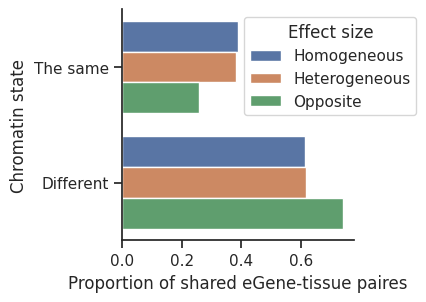

In [306]:
sns.set_theme(style="ticks")
fig=plt.figure(figsize=(3, 3))

ax = sns.barplot(df_split_states_prop, y="state_compare", x="proportion", order=order, hue="type", hue_order=hue_order)
ax.set_ylabel('Chromatin state')
ax.set_xlabel('Proportion of shared eGene-tissue pairs')
sns.move_legend(ax, "upper right", title='Effect size', bbox_to_anchor=(1.3, 1))
sns.despine()
plt.savefig('pdf/shared_egene_states.pdf', bbox_inches='tight')

# Fig. 5i-k

In [11]:
# locus plot
from matplotlib.colors import ListedColormap

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_cmap = cmap(np.linspace(minval, maxval, n))
    return ListedColormap(new_cmap)
    
def qtl_locusplot(plot_df, plot_dfs, phenotype_id, chrom, tis1, tis2, variant_id1, variant_id2,
                  rsid1=None, rsid2=None, ha="center", bar_orientation="horizontal", xlimit=None): 
    # prepare data
    ## non sig.
    if plot_df.empty:
        warnings.warn("No non-sig. variant exists in both tissues!", UserWarning)
    else:
        plot_df['position'] = plot_df['variant_id'].str.split('_', expand=True)[1].astype(int)/1e6
        plot_df['-log10(p-value)'] = -np.log10(plot_df["pval_nominal"])
        #plot_df['color'] = plot_df['tissue'].map({tis1:"#DBE9F6", tis2:"#FEDBCC"})
    ## sig.
    plot_dfs['position'] = plot_dfs['variant_id'].str.split('_', expand=True)[1].astype(int)/1e6
    plot_dfs['-log10(p-value)'] = -np.log10(plot_dfs["pval_nominal"])
    plot_dfs1 = plot_dfs[plot_dfs['tissue']==tis1]
    plot_dfs2 = plot_dfs[plot_dfs['tissue']==tis2]
    
    variant_id1_bp = plot_dfs1.loc[plot_dfs1['variant_id']==variant_id1, 'position']
    variant_id2_bp = plot_dfs2.loc[plot_dfs2['variant_id']==variant_id2, 'position']
    variant_id1_slope = plot_dfs1.loc[plot_dfs1['variant_id']==variant_id1, 'slope'].values[0]
    variant_id2_slope = plot_dfs2.loc[plot_dfs2['variant_id']==variant_id2, 'slope'].values[0]
    variant_id1_p = plot_dfs1.loc[plot_dfs1['variant_id']==variant_id1, '-log10(p-value)'].values[0]
    variant_id2_p = plot_dfs2.loc[plot_dfs2['variant_id']==variant_id2, '-log10(p-value)'].values[0]

    # plot
    sns.set_theme(style="ticks")
    plt.figure(figsize=(5.5, 3))
    #plt.axhline(y=0, color='grey', alpha=.5, linestyle='--')

    ## scatter plots (non sig.)
    if not plot_df.empty:
        plt.scatter(x=plot_df['position'], y=plot_df['slope'], c="gainsboro", s=30, edgecolors=None)
    
    ## scatter plots (sig.)
    cmap1 = plt.get_cmap("Blues")
    truncated_cmap1 = truncate_colormap(cmap1, minval=0.325, maxval=1.0)
    plt.scatter(x=plot_dfs1['position'], y=plot_dfs1['slope'], c=plot_dfs1['-log10(p-value)'],  s=30, edgecolors=None,
                cmap=truncated_cmap1)
    cmap2 = plt.get_cmap("Reds")
    truncated_cmap2 = truncate_colormap(cmap2, minval=0.325, maxval=1.0)
    plt.scatter(x=plot_dfs2['position'], y=plot_dfs2['slope'], c=plot_dfs2['-log10(p-value)'], s=30, edgecolors=None,
                cmap=truncated_cmap2)

    ## highlights
    plt.scatter(variant_id1_bp, variant_id1_slope, color='Blue', marker='D', s=80, edgecolor='black')
    plt.scatter(variant_id2_bp, variant_id2_slope, color='Red', marker='D', s=80, edgecolor='black')
    if rsid1:
        plt.text(variant_id1_bp*1.0001, variant_id1_slope*0.99, f'top-eQTL: {rsid1}\n'+"-log10P = "+f'{variant_id1_p:.2f}, β = {variant_id1_slope:.2f}',
             ha=ha, va="top")
    else:
        plt.text(variant_id1_bp*1.0001, variant_id1_slope*0.99, f'top-eQTL: {variant_id1}\n'+"-log10P = "+f'{variant_id1_p:.2f}, β = {variant_id1_slope:.2f}',
             ha=ha, va="top")
    if rsid2:
        plt.text(variant_id2_bp*1.0001, variant_id2_slope*1.01, f'top-eQTL: {rsid2}\n'+"-log10P = "+f'{variant_id2_p:.2f}, β = {variant_id2_slope:.2f}',
             ha=ha, va="bottom")
    else:
        plt.text(variant_id2_bp*1.0001, variant_id2_slope*1.01, f'top-eQTL: {variant_id2}\n'+"-log10P = "+f'{variant_id2_p:.2f}, β = {variant_id2_slope:.2f}',
             ha=ha, va="bottom")
        
    ## set labels
    plt.ylim(pd.concat([plot_df['slope'], plot_dfs['slope']]).min()*1.2, pd.concat([plot_df['slope'], plot_dfs['slope']]).max()*1.2)
    if xlimit:
        plt.xlim(xlimit)
    plt.xlabel(f"Position on {chrom} (Mb)")
    plt.ylabel("Effect size")
    plt.title(phenotype_id, style="italic")
    
    ## color bar1
    norm = plt.Normalize(vmin=plot_dfs1['-log10(p-value)'].max(), vmax=plot_dfs1['-log10(p-value)'].min())
    sm = plt.cm.ScalarMappable(cmap=truncated_cmap1, norm=norm)
    if bar_orientation=="horizontal":
        cax = plt.axes([0.2, -0.21, 0.2, 0.05])  # 调整位置和大小
        cbar = plt.colorbar(sm, cax=cax, spacing='proportional', orientation='horizontal')
        cax.set_title("-log10P"+f" ({tis1})")
    elif bar_orientation=="vertical":
        cax = plt.axes([1, 0.5, 0.03, 0.3])  # 调整位置和大小
        cbar = plt.colorbar(sm, cax=cax, spacing='proportional', orientation='vertical')
        cax.set_title("-log10P"+f"\n({tis1})")
    cbar.ax.xaxis.set_label_position('top')
    
    ## color bar2
    norm = plt.Normalize(vmin=plot_dfs2['-log10(p-value)'].max(), vmax=plot_dfs2['-log10(p-value)'].min())
    sm = plt.cm.ScalarMappable(cmap=truncated_cmap2, norm=norm)
    if bar_orientation=="horizontal":
        cax = plt.axes([0.6, -0.21, 0.2, 0.05])  # 调整位置和大小
        cbar = plt.colorbar(sm, cax=cax, spacing='proportional', orientation='horizontal')
        cax.set_title("-log10P"+f" ({tis2})")
    elif bar_orientation=="vertical":
        cax = plt.axes([1, 0, 0.03, 0.3])  # 调整位置和大小
        cbar = plt.colorbar(sm, cax=cax, spacing='proportional', orientation='vertical')
        cax.set_title("-log10P"+f"\n({tis2})")
    cbar.ax.xaxis.set_label_position('top')

    sns.despine()

In [12]:
# SNP expression
from pysam import VariantFile
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm

def removeBatchEffect(expr, covariates):
    """
    equal to limma::removeBatchEffect()
    input:
        expr: expression matrix (sample × gene), DataFrame
        covariates: covariate matrix (sample × PCs), DataFrame
    """
    X = sm.add_constant(covariates)
    residuals = pd.DataFrame(index=expr.index, columns=expr.columns)
    
    for gene in expr.columns:
        y = expr[gene]
        model = sm.OLS(y, X)
        results = model.fit()
        residuals[gene] = results.resid + results.params[0]
        
    return residuals

def load_tmm(tmm_file, batch_file, vcf_file, phenotype_id, variant_id, tis):
    chrom = 'chr' + variant_id.split('_')[0]
    position = int(variant_id.split('_')[1])
    # input genotypes
    vcf_in = VariantFile(vcf_file)
    rec_list = []
    for rec in vcf_in.fetch(chrom, position-1, position):
        rec_dict = {'chrom': rec.chrom, 'pos': rec.pos, 'id': rec.id, 'ref': rec.ref, 'alt': rec.alts[0]}
        for sample in rec.samples:
            rec_dict[sample] = sum(rec.samples[sample]['GT'])
        rec_list.append(rec_dict)
    genotype_df = pd.DataFrame(rec_list)
    genotype_s = genotype_df[genotype_df['id'] == variant_id].iloc[0]
    ref = genotype_s['ref'] + '/' + genotype_s['ref']
    het = genotype_s['ref'] + '/' + genotype_s['alt']
    alt = genotype_s['alt'] + '/' + genotype_s['alt']
    genotype_s = genotype_s[5:].astype(int)
    sample_list = genotype_s.index.to_list()
    
    # input phenotype + batch
    phenotype_df = pd.read_csv(tmm_file, sep="\t", index_col=3).iloc[:, 3:]
    phenotype_s = phenotype_df.loc[phenotype_id]
    batch_df = pd.read_csv(batch_file, sep="\t", index_col=0)
    corrected_phenotype_s = removeBatchEffect(phenotype_s.to_frame(), batch_df.T).iloc[:, 0]
    
    # reindex
    phenotype_s = phenotype_s.reindex(sample_list)
    corrected_phenotype_s = corrected_phenotype_s.reindex(sample_list)
    
    # grouping
    df = pd.DataFrame({'phenotype': phenotype_s, 'genotype': genotype_s})
    df.loc[df.index.str.contains(f'_{tis}'), 'tissue'] = tis
    df['genotype'] = df['genotype'].astype(int)
    
    # rename
    df['genotype0'] = df['genotype'].replace({0:ref, 1:het, 2:alt})
    df = df.sort_values(by='genotype', ascending=True)
    
    # corrected df
    corrected_df = pd.DataFrame({'phenotype': corrected_phenotype_s, 'genotype': genotype_s})
    corrected_df.loc[corrected_df.index.str.contains(f'_{tis}'), 'tissue'] = tis
    corrected_df['genotype'] = corrected_df['genotype'].astype(int)
    corrected_df['genotype0'] = corrected_df['genotype'].replace({0:ref, 1:het, 2:alt})
    corrected_df = corrected_df.sort_values(by='genotype', ascending=True)

    return df, corrected_df, ref, alt


def load_group_tmm(tmm_file1, tmm_file2, batch_file1, batch_file2, vcf_file1, vcf_file2, phenotype_id, variant_id, tis1, tis2):
    chrom = 'chr' + variant_id.split('_')[0]
    position = int(variant_id.split('_')[1])
    # input genotpyes
    genotype_s = pd.Series()
    for vcf_file in [vcf_file1, vcf_file2]:
        vcf_in = VariantFile(vcf_file)  # auto-detect input format
        rec_list = []
        for rec in vcf_in.fetch(chrom, position-1, position):
            rec_dict = {'chrom': rec.chrom, 'pos': rec.pos, 'id': rec.id, 'ref': rec.ref, 'alt': rec.alts[0]}
            for sample in rec.samples:
                rec_dict[sample] = sum(rec.samples[sample]['GT'])
            rec_list.append(rec_dict)
        genotype_df = pd.DataFrame(rec_list)
        genotype_s_ = genotype_df[genotype_df['id']==variant_id].iloc[0]
        genotype_s = pd.concat([genotype_s, genotype_s_[5:]], axis=0).astype(int)

    sample_list = genotype_s.index.to_list()
    # input phenotype1 and batch1
    phenotype_df1 = pd.read_csv(tmm_file1, sep="\t", index_col=3)
    phenotype_df1 = phenotype_df1.iloc[:, 3:]
    phenotype_s1 = phenotype_df1.loc[phenotype_id]
    batch_df1 = pd.read_csv(batch_file1, sep="\t", index_col=0)
    corrected_phenotype_s1 = removeBatchEffect(phenotype_s1.to_frame(), batch_df1.T)
    
    # input phenotype2 and batch2
    phenotype_df2 = pd.read_csv(tmm_file2, sep="\t", index_col=3)
    phenotype_df2 = phenotype_df2.iloc[:, 3:]
    phenotype_s2 = phenotype_df2.loc[phenotype_id]
    batch_df2 = pd.read_csv(batch_file2, sep="\t", index_col=0)
    corrected_phenotype_s2 = removeBatchEffect(phenotype_s2.to_frame(), batch_df2.T)
    
    # merge phenotypes
    phenotype_s = pd.concat([phenotype_s1, phenotype_s2]).reindex(sample_list)
    corrected_phenotype_s = pd.concat([corrected_phenotype_s1, corrected_phenotype_s2]).reindex(sample_list).iloc[:, 0]
    
    # grouping
    df = pd.DataFrame({'phenotype': phenotype_s, 'genotype': genotype_s})
    df.loc[df.index.str.contains(f'_{tis1}'), 'tissue'] = tis1
    df.loc[df.index.str.contains(f'_{tis2}'), 'tissue'] = tis2
    df['genotype'] = df['genotype'].astype(int)

    # rename
    ref = genotype_s_['ref'] + '/' + genotype_s_['ref']
    het = genotype_s_['ref'] + '/' + genotype_s_['alt']
    alt = genotype_s_['alt'] + '/' + genotype_s_['alt']
    df['genotype0'] = df['genotype'].replace({0:ref, 1:het, 2:alt})
    df = df.sort_values(by='genotype', ascending=True)

    # grouping (corrected matrix)
    corrected_df = pd.DataFrame({'phenotype': corrected_phenotype_s, 'genotype': genotype_s})
    corrected_df.loc[corrected_df.index.str.contains(f'_{tis1}'), 'tissue'] = tis1
    corrected_df.loc[corrected_df.index.str.contains(f'_{tis2}'), 'tissue'] = tis2
    corrected_df['genotype'] = corrected_df['genotype'].astype(int)
    
    # rename (corrected matrix)
    corrected_df['genotype0'] = corrected_df['genotype'].replace({0:ref, 1:het, 2:alt})
    corrected_df = corrected_df.sort_values(by='genotype', ascending=True)
    
    return df, corrected_df, genotype_s_['ref'], genotype_s_['alt']
    

def plot_tmm(df, phenotype_id, variant_id, tis1, tis2):
    sns.set_theme(style="ticks")
    fig, ax = plt.subplots(figsize=(2.5, 2.5))
    
    ax = sns.stripplot(data=df, x='genotype0', y='phenotype', hue="tissue", hue_order=[tis1, tis2],
                       alpha=0.5, dodge=True, legend=False)
    
    ax = sns.boxplot(data=df, x='genotype0', y='phenotype', hue="tissue", hue_order=[tis1, tis2],
                     gap=0.2, fill=False, showfliers=False, dodge=True)
    
    for i, tissue in enumerate([tis1, tis2]):
        ax = sns.regplot(data=df[df['tissue']==tissue], x='genotype', y='phenotype',
                         scatter=None, color=sns.color_palette()[i])
    
    plt.legend(title=None)
    plt.xlabel(variant_id)
    sns.move_legend(ax, "lower left", bbox_to_anchor=(0.1, -0.6))
    plt.title(phenotype_id, style="italic")
    sns.despine()

    return ax

In [13]:
# Chromatin states
from matplotlib.patches import Rectangle
import matplotlib.ticker as mticker

def plot_chromatin_blocks(state_path, tislist, chrom, region, highlight=None, annot_df=None, ld_block=None, figsize=(7, 5)):
    label_mapping = {1:"TssA", 2:"TssAHet", 3:"TxFlnk", 4:"TxFlnkWk", 5:"TxFlnkHet", 6:"EnhA", 7:"EnhAMe", 8:"EnhAWk",
                     9:"EnhAHet", 10:"EnhPois", 11:"ATAC_Is", 12:"TssBiv", 13:"Repr", 14:"ReprWk", 15:"Qui"}
    
    # input data
    chrom = region.split(':')[0]
    chrnum = chrom.split('chr')[1]
    start = int(region.split(':')[1].split('-')[0])
    end = int(region.split(':')[1].split('-')[1])
    state_filelist = os.listdir(state_path)
    df = pd.DataFrame()
    for tissue in tislist:
        df_ = pd.read_csv(f'{state_path}/{tissue}_18_dense.bed', sep="\t", header=None, skiprows=1, usecols=[0,1,2,3,8], names=['CHROM', 'BIN_START', 'BIN_END', 'state', 'color'])
        df_['tissue'] = tissue
        df = pd.concat([df, df_])
    
    df['state'] = df['state'].map(label_mapping).fillna(df['state'])
    df['RGBA'] = df['color'].apply(lambda x: tuple(int(i)/255 for i in x.split(',')) if isinstance(x, str) else x)
    df['start'] = df['BIN_START']/1e6
    df['end'] = df['BIN_END']/1e6

    # plot
    dfplot = df[(df['CHROM']==chrom)&(df['BIN_START']>=start)&(df['BIN_START']<=end)]
    
    ## colormap
    states_all = list(label_mapping.values())
    state_colors = dfplot[['state', 'RGBA']].drop_duplicates().set_index('state')['RGBA'].to_dict()
    states = [s for s in states_all if s in state_colors]
    
    ## subplot for each tissue
    sns.set_theme(style="ticks")
    fig, axes = plt.subplots(len(tislist)+1, 1, sharex=True, figsize=figsize)

    ## highlight
    if highlight:
        axes[0].text(highlight/1e6, 0.5, '*', ha='center', va='center', color='red')

    ## gene location
    if annot_df is not None and not annot_df.empty:
        for row in annot_df.itertuples():
            if row.strand == '+':
                axes[0].annotate(text=row.gene_id, xy=(row.end/1e6, 0.8), xytext=(row.start/1e6, 0.8), fontstyle='italic', ha='right', va='center',
                                 arrowprops=dict(arrowstyle='->,head_width=0.3,head_length=1',color="black"), clip_on=False)
            else:
                axes[0].annotate(text=row.gene_id, xy=(row.start/1e6, 0.8), xytext=(row.end/1e6, 0.8), fontstyle='italic', ha='left', va='center',
                                 arrowprops=dict(arrowstyle='->,head_width=0.3,head_length=1',color="black"), clip_on=False)
    
    axes[0].set_xlim(start/1e6, end/1e6)
    axes[0].set_ylim(0, 1)
    axes[0].set_yticks([])
    axes[0].set_ylabel('')

    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)
    axes[0].spines['bottom'].set_visible(False)
    axes[0].spines['left'].set_visible(False)

    ## LD block, calculated by plink --blocks no-pheno-req, file path: /storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v9.breed_specific/admixture/chrAuto.blocks.det
    if ld_block:
        ld_start = ld_block[0]
        ld_end =  ld_block[1]
        rect = Rectangle((ld_start/1e6, 0), (ld_end-ld_start)/1e6, 0.2, facecolor='red', edgecolor='none', alpha=0.2)
        axes[0].add_patch(rect)
        
    for idx, tissue in enumerate(tislist, 1):
        ax = axes[idx]

        # plot each block
        for state in states[::-1]:
            tissue_state_df = dfplot[(dfplot['tissue']==tissue)&(dfplot['state']==state)]
            for _, row in tissue_state_df.iterrows():
                rect = Rectangle((row['start'], 0), row['end']-row['start'], 1, facecolor=row['RGBA'], edgecolor='none')
                ax.add_patch(rect)
        ax.set_xlim(start/1e6, end/1e6)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_ylabel(tissue, ha='right', va='center', fontsize=7, rotation=0)
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
        
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        # xlabel
        if idx == len(tislist):
            ax.set_xlabel(f'Chromosome {chrnum} (Mb)')
        else:
            ax.tick_params(length=0)
    
    # fig legend
    legend_patches = [Rectangle((0,0), 1, 1, color=state_colors[s]) for s in states]
    fig.legend(legend_patches, states, title='Chromatin states', loc='upper left', bbox_to_anchor=(1, 1), ncol=3)


In [14]:
annot_file = '/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/01.MP1/02.stat/04.MP1/gene.bed'
annot = pd.read_csv(annot_file, sep='\t', header=None, names=['chr', 'start', 'end', 'gene_id', 'strand'])
annot

,chr,start,end,gene_id,strand
0,chr1,46754,48356,LOC114112203,-
1,chr1,51268,52870,LOC114110836,-
2,chr1,74991,78012,LOC114113923,-
3,chr1,78474,85477,LOC114112459,+
4,chr1,117916,129472,FAM240C,+
...,...,...,...,...,...
25694,chrMT,9884,10181,KEF53_p05,+
25695,chrMT,10174,11552,KEF53_p04,+
25696,chrMT,11753,13574,KEF53_p03,+
25697,chrMT,13557,14085,KEF53_p02,-


In [15]:
# Significant molQTL results
dfs = pd.read_csv(f'{path0}/tensorqtl_cis_qtl_pairs.sig.txt.gz', sep='\t')
dfs

,tissue,phenotype_id,variant_id,start_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,pval_nominal_threshold
0,Muscle,LOC114113923,1_75039,-2973,0.856943,169,204,3.565399e-07,-0.269607,0.052434,2.061963e-04
1,Muscle,LOC114113923,1_75054,-2958,0.856241,171,205,1.156632e-06,-0.258615,0.052698,2.061963e-04
2,Muscle,LOC114113923,1_165396,87384,0.057504,77,82,6.327027e-06,0.377237,0.082890,2.061963e-04
3,Muscle,LOC114113923,1_165713,87701,0.056802,76,81,1.533038e-05,0.361561,0.083012,2.061963e-04
4,Muscle,LOC114113923,1_167321,89309,0.053997,73,77,1.460638e-04,0.329361,0.086234,2.061963e-04
...,...,...,...,...,...,...,...,...,...,...,...
19054278,Oviduct,LOC121817967,25_34422862,823950,0.087500,7,7,4.341633e-07,0.720379,0.106505,9.726244e-07
19054279,Oviduct,LOC121817967,25_34423371,824459,0.100000,8,8,2.094183e-09,0.675480,0.074262,9.726244e-07
19054280,Oviduct,LOC121817967,25_34423498,824586,0.100000,8,8,6.081651e-08,0.634744,0.083655,9.726244e-07
19054281,Oviduct,LOC121817967,25_34425348,826436,0.075000,6,6,2.514919e-10,0.852121,0.084195,9.726244e-07


In [16]:
path = "/storage/public/home/2020060185/00.sheep_goatGTEx/01.sheepGTEx/03.QTL/01.eQTL/v6.tissue_sharing/oppo_effect"
df = pd.read_csv(f"{path}/oppo_effect_eqtl.txt", sep="\t",
                  usecols=['tissue1', 'tissue2', 'phenotype_id', 'chrom', 'variant_id1', 'pval_nominal1', 'slope1', 'slope_se1', 'shared1',
                           'variant_id2', 'pval_nominal2', 'slope2', 'slope_se2', 'shared2', 'PP.H4.abf', 'r2_min', 'type'])
df['chrom'] = 'chr' + df['variant_id1'].str.split('_', expand=True)[0]

In [19]:
tis1, tis2, phenotype_id = "Testis.Ileum.TFF2".split('.')[0:3]

df_het_oppo = df[(df['tissue1']==tis1)&(df['tissue2']==tis2)&(df['r2_min']>=0.8)&(df['shared1']==True)&(df['shared2']==True)]
dfs1 = pd.read_csv(f"{path0}/{tis1}/results/tensorqtl/nominal/{tis1}.cis_qtl_pairs.sig.txt.gz", sep="\t")
dfs2 = pd.read_csv(f"{path0}/{tis2}/results/tensorqtl/nominal/{tis2}.cis_qtl_pairs.sig.txt.gz", sep="\t")
dfs1['tissue'] = tis1
dfs2['tissue'] = tis2
dfs1_ = dfs1[dfs1['phenotype_id']==phenotype_id]
dfs2_ = dfs2[dfs2['phenotype_id']==phenotype_id]

row1 = df_het_oppo[df_het_oppo['phenotype_id']==phenotype_id]
chrom0 = ''
chrom = row1.chrom.values[0]

if chrom != chrom0:
    df1 = pd.read_csv(f"{path0}/{tis1}/results/tensorqtl/nominal/{tis1}.cis_qtl_pairs.{chrom}.txt.gz", sep="\t")
    df2 = pd.read_csv(f"{path0}/{tis2}/results/tensorqtl/nominal/{tis2}.cis_qtl_pairs.{chrom}.txt.gz", sep="\t")
    df1['tissue'] = tis1
    df2['tissue'] = tis2
    chrom0 = chrom
variant_id1 = row1.variant_id1.values[0]
variant_id2 = row1.variant_id2.values[0]
df1_ = df1[df1['phenotype_id']==phenotype_id]
df2_ = df2[df2['phenotype_id']==phenotype_id]

# extract non sig. results
df1_plot = df1_[~df1_['variant_id'].isin(dfs1_['variant_id'])]
df2_plot = df2_[~df2_['variant_id'].isin(dfs2_['variant_id'])]

# plot
plot_dfs = pd.concat([dfs1_, dfs2_]).dropna().sort_values(by='pval_nominal', ascending=False)
plot_df = pd.concat([df1_plot, df2_plot]).dropna().sort_values(by='pval_nominal', ascending=False)

In [20]:
variant_id1

'1_263297392'

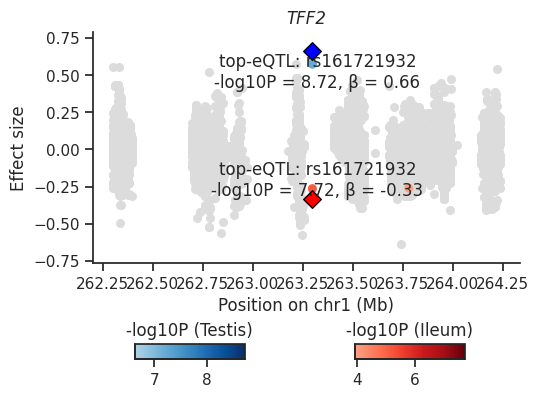

In [21]:
rsid = 'rs161721932'
qtl_locusplot(plot_df, plot_dfs, phenotype_id, chrom, tis1, tis2, variant_id1, variant_id1, rsid1=rsid, rsid2=rsid)
#plt.savefig("pdf/TFF2_locus_plot.pdf", bbox_inches="tight")

In [22]:
dfs.loc[(dfs['phenotype_id']==phenotype_id)&(dfs['variant_id']==variant_id1), ['tissue', 'slope']]

,tissue,slope
1900663,Liver,0.254394
4467457,Brain,0.242097
9292533,Hypothalamus,0.457480
10354484,Heart,0.628974
13074750,Ileum,-0.330438
14011880,Cerebellum,0.407536
18857499,Testis,0.659165


In [23]:
# across all significant tissues
tmm_df = pd.DataFrame()
corrected_tmm_df = pd.DataFrame()

for tis in ['Ileum', 'Testis', 'Liver', 'Brain', 'Cerebellum', 'Hypothalamus', 'Heart']:
    print(tis)
    tmm_file = f'{path0}/{tis}/phenotypes/{tis}.expression.bed.gz'
    batch_file = f'{path0}/{tis}/covFile/{tis}.tsv'
    vcf_file = f'{path0}/{tis}/genotypes/{tis}.vcf.gz'
    tmm_df_, corrected_tmm_df_, ref, alt = load_tmm(tmm_file, batch_file, vcf_file, phenotype_id, variant_id1, tis)
    tmm_df = pd.concat([tmm_df, tmm_df_])
    corrected_tmm_df = pd.concat([corrected_tmm_df, corrected_tmm_df_])

Ileum
Testis
Liver
Brain
Cerebellum
Hypothalamus
Heart


In [24]:
corrected_tmm_df.groupby(['tissue', 'genotype0'])['genotype'].count()

tissue        genotype0
Brain         C/C          183
              C/T          228
              T/T           70
Cerebellum    C/C           52
              C/T           84
              T/T           33
Heart         C/C           77
              C/T           45
              T/T           86
Hypothalamus  C/C           63
              C/T          108
              T/T           57
Ileum         C/C           92
              C/T           61
              T/T           25
Liver         C/C          222
              C/T          147
              T/T          198
Testis        C/C           13
              C/T           21
              T/T           31
Name: genotype, dtype: int64

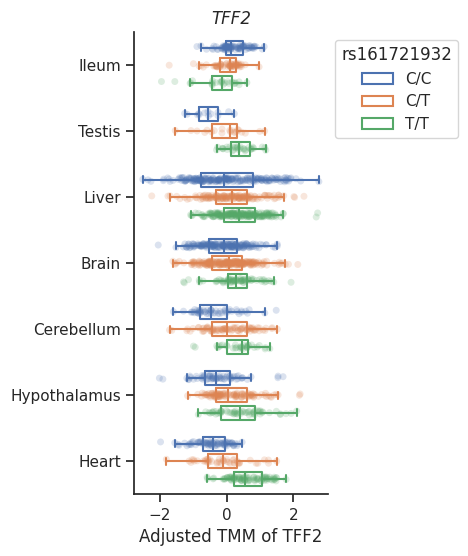

In [25]:
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(2.5, 6))

ax = sns.stripplot(data=corrected_tmm_df,  y='tissue', x='phenotype', hue="genotype0",
                   hue_order=['C/C', 'C/T', 'T/T'], alpha=0.2, dodge=True, legend=False)
ax = sns.boxplot(data=corrected_tmm_df, y='tissue', x='phenotype', hue="genotype0",
                 hue_order=['C/C', 'C/T', 'T/T'], gap=0.2, showfliers=False,
                 fill=False, dodge=True)

plt.xlabel(f'Adjusted TMM of {phenotype_id}')
plt.ylabel('')
sns.move_legend(ax, "upper left", title=rsid, bbox_to_anchor=(1, 1))
plt.title(phenotype_id, style="italic")

sns.despine()
#plt.savefig("pdf/TFF2_tissue_allele.pdf", bbox_inches="tight")

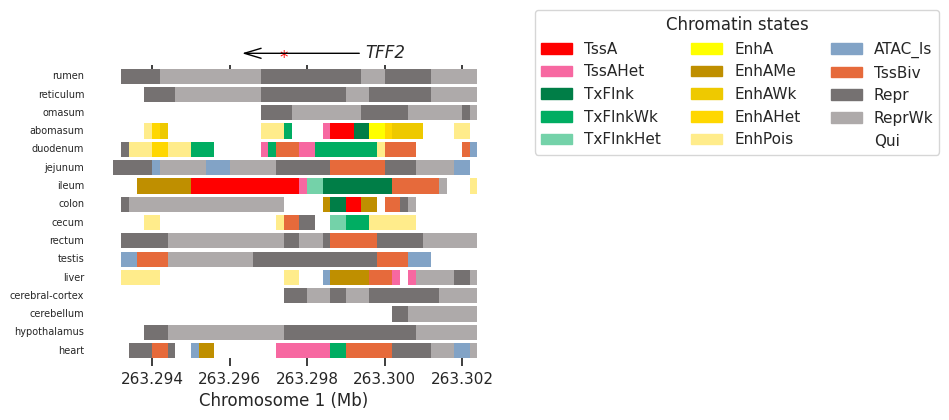

In [26]:
state_path = '/storage/public/home/2020060185/genome/sheep/chromHMM_dense'
#tislist = mapping[tis1] + mapping[tis2]
#tislist = ['rumen', 'reticulum', 'omasum', 'abomasum', 'duodenum', 'jejunum', 'ileum', 'colon', 'cecum', 'rectum', 'testis', 'ovary', 'muscle', 'liver', 'adipose', 'pituitary', 'spleen', 'skin']
tislist = ['rumen', 'reticulum', 'omasum', 'abomasum', 'duodenum', 'jejunum', 'ileum', 'colon', 'cecum', 'rectum',
           'testis', 'liver', 'cerebral-cortex', 'cerebellum', 'hypothalamus', 'heart']
pos = int(variant_id1.split('_')[1])
annot_df = annot[annot['gene_id']==phenotype_id]
region_highlight_range=(pos - 5000, pos + 5000)
region_highlight = f'{chrom}:{region_highlight_range[0]}-{region_highlight_range[1]}'
plot_chromatin_blocks(state_path, tislist, chrom, region_highlight, highlight=pos, annot_df=annot_df, figsize=(5, 4))
#plt.savefig("pdf/TFF2_chromatin.pdf", bbox_inches="tight")